# Time Series Forecasting for Energy Analytics - NSP Dataset

## Objective
Build Prophet and LSTM forecasting models for all 5 regions using engineered features

## Setup and Imports

In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from prophet import Prophet
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import optuna

In [131]:
# path configurations
# Paths
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "output"

In [132]:
# Helper functions
model_results = {'Model': [], 'Region': [], 'MAE': [], 'RMSE': [], 'MAPE': []}


# metrics to be stored
def calculate_metrics(y_true, y_pred, model_name, region_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Return as a dictionary so we can add 'Predictions' to it later
    return {
        'Region': region_name,
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    }

# save and show the plot
def save_and_show_plot(fig, filename):
    output_path = OUTPUT_DIR / filename
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.show()


# check for GPU / CPU
def get_device():
    try:
        if torch.cuda.is_available():
            device = torch.device('cuda')
            # Test CUDA by running a small tensor operation
            test_tensor = torch.tensor([1.0, 2.0]).to(device)
            print(f"Test Tensor result: {test_tensor}")
            print(f"CUDA is working. Using device: {device}")
        else:
            device = torch.device('cpu')
            print("CUDA not available, using CPU")
    except Exception as ex:
        device = torch.device('cpu')
        print(f"Error initializing CUDA: {ex}")
        print("Falling back to CPU")
    return device

In [133]:
print(f"Current device: {get_device()}")

Test Tensor result: tensor([1., 2.], device='cuda:0')
CUDA is working. Using device: cuda
Current device: cuda


## Load Engineered Features Dataset

In [134]:
df = pd.read_csv(OUTPUT_DIR / "engineered_features.csv", parse_dates=["timestamp"])
display(df.columns)

display(df.shape)

Index(['timestamp', 'region', 'hour', 'day_of_week', 'month', 'year', 'week',
       'is_weekend', 'season', 'is_holiday', 'temperature_c', 'feels_like_c',
       'humidity_pct', 'wind_speed_kmh', 'precipitation_mm', 'cloud_cover_pct',
       'renewable_pct', 'consumption_kwh', 'price_per_kwh', 'grid_load_pct',
       'co2_kg', 'customer_type', 'demand_response', 'power_outage',
       'anomaly_flag', 'anomaly_type', 'peak_demand_flag',
       'consumption_kwh_lag_1h', 'consumption_kwh_lag_24h',
       'rolling_mean_168h', 'rolling_std_24h', 'heating_degree_day'],
      dtype='str')

(438240, 32)

In [135]:
# Verify key features exist
required_features = ['consumption_kwh_lag_1h', 'consumption_kwh_lag_24h',
                     'rolling_mean_168h', 'rolling_std_24h', 'heating_degree_day']

print("\nRequired features present:")
for feat in required_features:
    exists = feat in df.columns
    print(f"  {feat}: {'✓' if exists else '✗ MISSING'}")

# Handle region column (check if one-hot encoded or categorical)
if 'region' not in df.columns:
    region_cols = [col for col in df.columns if col.startswith('region_')]
    if region_cols:
        df['region'] = df[region_cols].idxmax(axis=1).str.replace('region_', '')
        print("\nReconstructed 'region' column from one-hot encoding")

print(f"\nRegions: {sorted(df['region'].unique())}")
print("\nSample data:")
df[['timestamp', 'region', 'consumption_kwh', 'consumption_kwh_lag_24h',
    'rolling_mean_168h', 'rolling_std_24h']].head()


Required features present:
  consumption_kwh_lag_1h: ✓
  consumption_kwh_lag_24h: ✓
  rolling_mean_168h: ✓
  rolling_std_24h: ✓
  heating_degree_day: ✓

Regions: ['Annapolis Valley', 'Cape Breton', 'Halifax', 'Pictou County', 'South Shore']

Sample data:


,timestamp,region,consumption_kwh,consumption_kwh_lag_24h,rolling_mean_168h,rolling_std_24h
0,2015-01-02 00:00:00,Annapolis Valley,114.19,125.53,205.136000,144.622016
1,2015-01-02 01:00:00,Annapolis Valley,113.90,94.93,201.626923,144.025200
2,2015-01-02 02:00:00,Annapolis Valley,96.57,103.48,197.735926,144.252549
3,2015-01-02 03:00:00,Annapolis Valley,112.05,82.12,194.675714,143.234144
4,2015-01-02 04:00:00,Annapolis Valley,124.48,81.56,192.255172,141.819107


In [136]:
for feature, data_type in zip(df.columns, df.dtypes):
    print(feature, data_type)

timestamp datetime64[us]
region str
hour int64
day_of_week int64
month int64
year int64
week int64
is_weekend int64
season str
is_holiday int64
temperature_c float64
feels_like_c float64
humidity_pct float64
wind_speed_kmh float64
precipitation_mm float64
cloud_cover_pct float64
renewable_pct float64
consumption_kwh float64
price_per_kwh float64
grid_load_pct float64
co2_kg float64
customer_type str
demand_response int64
power_outage int64
anomaly_flag int64
anomaly_type str
peak_demand_flag int64
consumption_kwh_lag_1h float64
consumption_kwh_lag_24h float64
rolling_mean_168h float64
rolling_std_24h float64
heating_degree_day float64


In [137]:
# Drop non-predictive or redundant columns
X = df.drop(columns=['consumption_kwh', 'timestamp'])
y = df['consumption_kwh']

## Find important features

In [138]:
# 3. Train Model
def get_important_features(X, y):
    # Encode categorical variables -> numericals
    cat_cols = X.select_dtypes(include=['object', "string"]).columns
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        le_dict[col] = le

    # Set tree_method to 'hist' and device to 'cuda'
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        tree_method='hist',
        device='cuda', # This triggers GPU usage
        random_state=42
    )

    xgb_model.fit(X, y)

    # 4. Extract Feature Importance
    importances = xgb_model.feature_importances_
    feature_names = X.columns
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)
    # save to csv
    feat_imp_df.to_csv(OUTPUT_DIR / 'feature_importance_results.csv', index=True)

    # plot the importance
    plt.figure(figsize=(10, 8))
    plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1])
    plt.xlabel('Importance')
    plt.title('Feature Importance for predicting consumption_kwh')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'feature_importance_plot_{len(X.columns)}.png')
    plt.show()
    print(feat_imp_df.head(20))

    return feat_imp_df.copy()

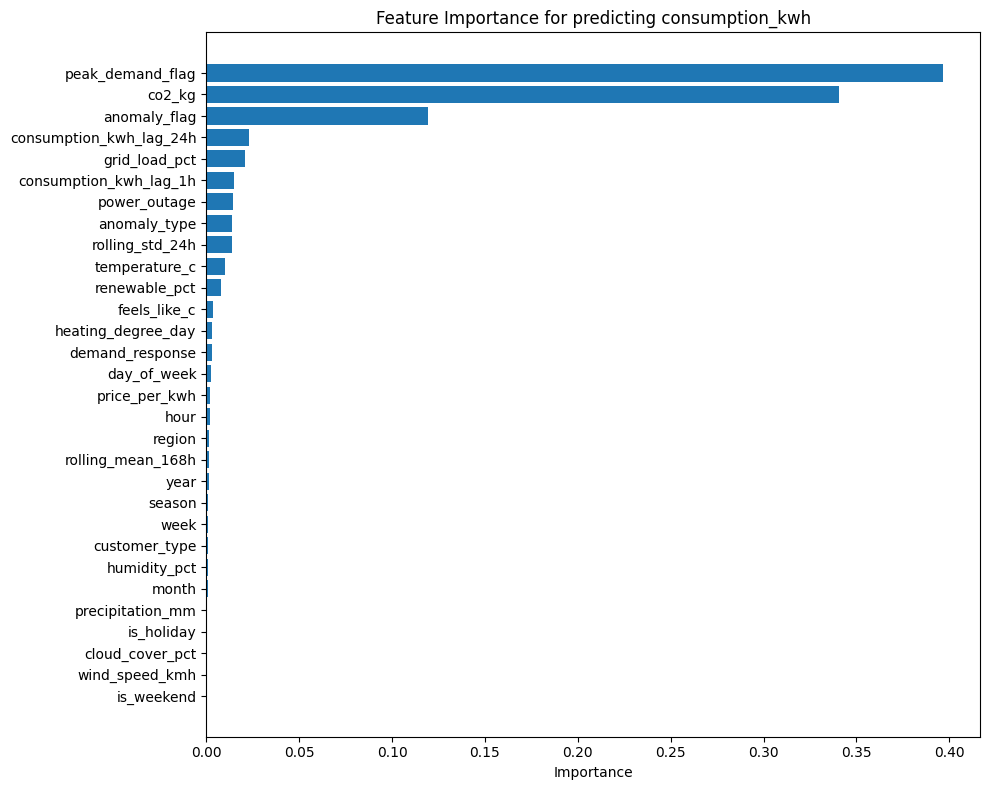

                    Feature  Importance
24         peak_demand_flag    0.396689
18                   co2_kg    0.340793
22             anomaly_flag    0.119337
26  consumption_kwh_lag_24h    0.023040
17            grid_load_pct    0.020662
25   consumption_kwh_lag_1h    0.015101
21             power_outage    0.014339
23             anomaly_type    0.013850
28          rolling_std_24h    0.013621
9             temperature_c    0.009844
15            renewable_pct    0.007890
10             feels_like_c    0.003319
29       heating_degree_day    0.002820
20          demand_response    0.002779
2               day_of_week    0.002419
16            price_per_kwh    0.001727
1                      hour    0.001703
0                    region    0.001577
27        rolling_mean_168h    0.001494
4                      year    0.001385


In [139]:
imp_features_1 = get_important_features(X, y)

## Thoughts on feature importance
The above results are garbage as Carbon Emissions and Peak Demand are calculated based on consumption data. Due to data-leakage we important features like hour, day_of_week are vanished.

### Recommended Fixes
To get a predictive model that actually works on future data, we should drop the "post-event" features.

Drop these "Leaked" Columns:
- co2_kg
- peak_demand_flag
- anomaly_flag / anomaly_type
- grid_load_pct

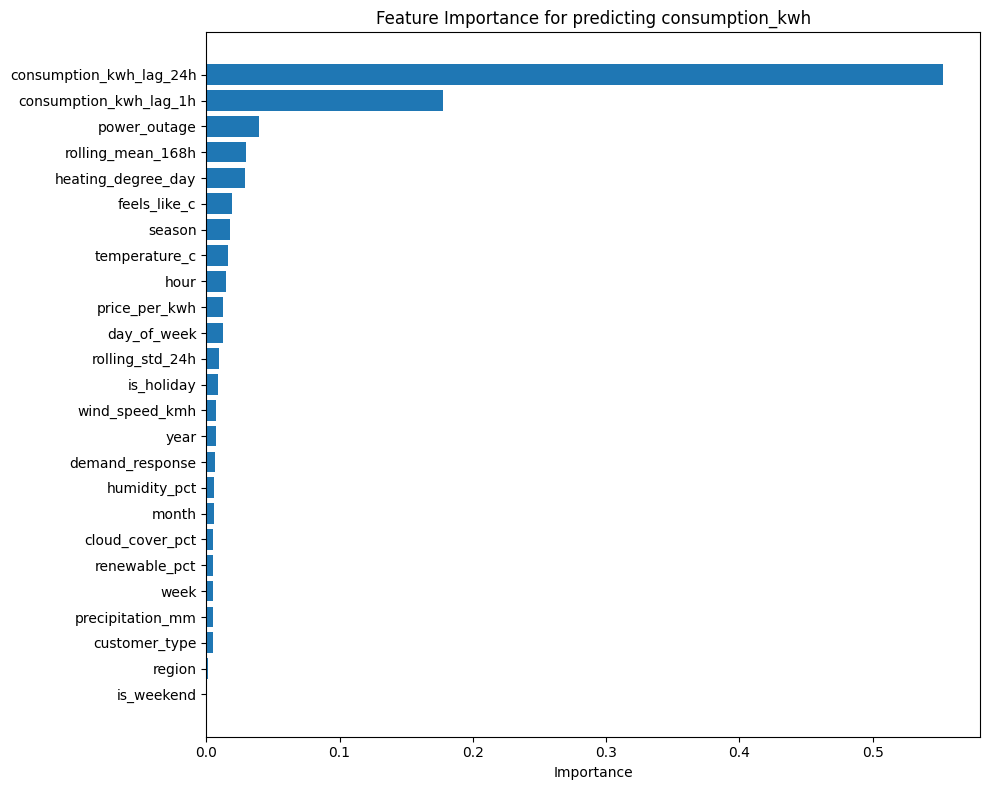

                    Feature  Importance
21  consumption_kwh_lag_24h    0.552954
20   consumption_kwh_lag_1h    0.177384
19             power_outage    0.039883
22        rolling_mean_168h    0.029683
24       heating_degree_day    0.029146
10             feels_like_c    0.019503
7                    season    0.017974
9             temperature_c    0.016565
1                      hour    0.014714
16            price_per_kwh    0.012447
2               day_of_week    0.012173
23          rolling_std_24h    0.009188
8                is_holiday    0.008915
12           wind_speed_kmh    0.007062
4                      year    0.006875
18          demand_response    0.006830
11             humidity_pct    0.006108
3                     month    0.005966
14          cloud_cover_pct    0.005210
15            renewable_pct    0.005074


In [140]:
X_clean = X.drop(columns=["co2_kg", "peak_demand_flag", "anomaly_flag", "anomaly_type", "grid_load_pct"])
y = df["consumption_kwh"]

imp_features_2 = get_important_features(X_clean, y)


## Correlation Analysis
---


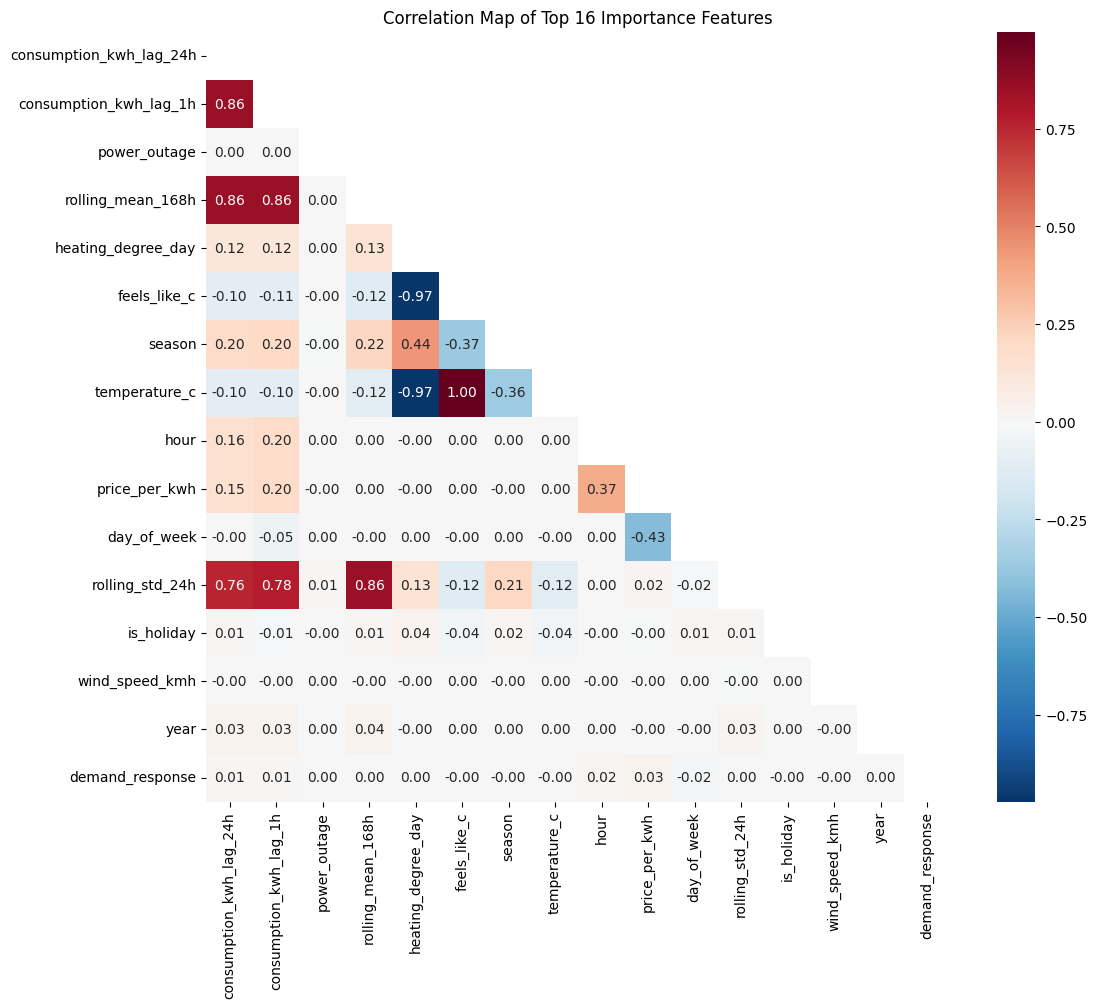

In [141]:
# Get the list of top 16 features from your pasted results
top_16_features = [
    'consumption_kwh_lag_24h', 'consumption_kwh_lag_1h', 'power_outage', 
    'rolling_mean_168h', 'heating_degree_day', 'feels_like_c', 'season', 
    'temperature_c', 'hour', 'price_per_kwh', 'day_of_week', 
    'rolling_std_24h', 'is_holiday', 'wind_speed_kmh', 'year', 'demand_response'
]

# Ensure we only use columns that exist in your X_clean and are numeric
# (Note: 'season' needs to be encoded or dropped for the correlation matrix)
X_top = X_clean[top_16_features].select_dtypes(include=[np.number])

# Compute Correlation
corr = X_top.corr()

# Plot
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool)) # Mask the upper triangle for clarity
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Correlation Map of Top 16 Importance Features")
plt.savefig(OUTPUT_DIR / "Feature_Correlation_Heatmap.png", dpi=300)
plt.show()

## Remove highly correlated features
---

 The Redundancy Hit ListBased on our correlation map, here are the features that are effectively telling the model the same thing:

1. The Weather Duo ($1.00$): temperature_c and feels_like_c have a perfect correlation ($1.00$ or $-0.97$). Keeping both is unnecessary.
    - Keep: heating_degree_day (Importance was higher and it’s a better linearizer).
    - Drop: temperature_c and feels_like_c.
2. The Lag Cluster ($0.86$): rolling_mean_168h is highly correlated with our lags.
    - Keep: consumption_kwh_lag_24h and consumption_kwh_lag_1h.
    - Drop: rolling_mean_168h.
3. The Rolling Volatility ($0.76$ - $0.86$): rolling_std_24h is strongly tied to the lags.
    - Action: 
    - If we want a simpler model, we should drop it. 
    - If we are specifically looking for anomaly detection (as we do), we are going to keep it, as it captures "unusual" movement.

In [142]:
def optimize_features(X, importance_df, threshold=0.85):
    # 1. Get the list of top features (sorted by importance)
    top_features = importance_df['Feature'].tolist()
    
    # 2. Calculate Correlation Matrix for these features
    corr_matrix = X[top_features].corr().abs()
    
    # 3. Identify pairs above the threshold
    to_drop = set()
    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            feature_i = top_features[i]
            feature_j = top_features[j]
            
            # If they are highly correlated and not already marked for dropping
            if corr_matrix.loc[feature_i, feature_j] > threshold:
                # Since the list is sorted by importance, 
                # feature_i is always more important than feature_j.
                # We keep the more important one and drop the other.
                to_drop.add(feature_j)
                print(f"Dropping '{feature_j}' (Corr: {corr_matrix.loc[feature_i, feature_j]:.2f} with '{feature_i}')")

    optimized_list = [f for f in top_features if f not in to_drop]
    return optimized_list

In [143]:
# --- Execution ---
# We keep 'anomaly_flag' out of X so it's not used for training, but stays in the dataframe
optimized_feature_names = optimize_features(X_clean, imp_features_2, threshold=0.85)

# Create the final training set
X_optimized = X_clean[optimized_feature_names]

print("\nFinal Optimized Feature Set:")
print(optimized_feature_names)

Dropping 'consumption_kwh_lag_1h' (Corr: 0.86 with 'consumption_kwh_lag_24h')
Dropping 'rolling_mean_168h' (Corr: 0.86 with 'consumption_kwh_lag_24h')
Dropping 'rolling_mean_168h' (Corr: 0.86 with 'consumption_kwh_lag_1h')
Dropping 'rolling_std_24h' (Corr: 0.86 with 'rolling_mean_168h')
Dropping 'feels_like_c' (Corr: 0.97 with 'heating_degree_day')
Dropping 'temperature_c' (Corr: 0.97 with 'heating_degree_day')
Dropping 'temperature_c' (Corr: 1.00 with 'feels_like_c')
Dropping 'week' (Corr: 0.97 with 'month')

Final Optimized Feature Set:
['consumption_kwh_lag_24h', 'power_outage', 'heating_degree_day', 'season', 'hour', 'price_per_kwh', 'day_of_week', 'is_holiday', 'wind_speed_kmh', 'year', 'demand_response', 'humidity_pct', 'month', 'cloud_cover_pct', 'renewable_pct', 'precipitation_mm', 'customer_type', 'region', 'is_weekend']


## Split the dataset
---
We use the full dataframe df to ensure we keep the timestamp and consumption_kwh alongside your optimized features.

Train, Validation, Test = 80%, 10%, 10%

In [144]:
# Sort by time to prevent data leakage
df = df.sort_values('timestamp')

# Define features and target
features = optimized_feature_names # The list from your previous step
target = 'consumption_kwh'

# 80/10/10 Split
n = len(df)
train_df = df.iloc[:int(n*0.8)]
val_df = df.iloc[int(n*0.8):int(n*0.9)]
test_df = df.iloc[int(n*0.9):]

In [145]:
display(train_df.shape)
display(val_df.shape)
display(test_df.shape)

(350592, 32)

(43824, 32)

(43824, 32)

## Region-wise Forecasting


## Prophet Forecasting - All Regions with Regressors

Features used as regressors:
- consumption_kwh (target)
- Lag features: lag_1h, lag_24h
- Rolling statistics: rolling_mean_168h, rolling_std_24h
- hdd (Heating Degree Days)
- is_holiday

We'll forecast each region separately with 80/20 train/test split.

In [146]:
def run_prophet_regionally(df, features):
    regions = df['region'].unique()
    results = []
    
    for reg in regions:
        print(f"Prophet: Processing {reg}...")
        reg_df = df[df['region'] == reg].sort_values('timestamp').copy()
        
        # Explicitly include 'string' to silence the Pandas4Warning
        char_cols = reg_df[features].select_dtypes(include=['object', 'string']).columns
        for col in char_cols:
            reg_df[col] = LabelEncoder().fit_transform(reg_df[col].astype(str))
            
        train_idx = int(len(reg_df) * 0.8)
        train, test = reg_df.iloc[:train_idx], reg_df.iloc[train_idx:]
        
        # # type: ignore handles the Pylance typing issue
        m = Prophet(daily_seasonality=True, weekly_seasonality=True) # type: ignore
        for col in features:
            m.add_regressor(col)
            
        train_p = train[['timestamp', 'consumption_kwh'] + features].rename(columns={'timestamp': 'ds', 'consumption_kwh': 'y'})
        m.fit(train_p)
        
        forecast = m.predict(test[['timestamp'] + features].rename(columns={'timestamp': 'ds'}))
        
        # Ensure metrics is a dictionary (from our updated calculate_metrics function)
        metrics = calculate_metrics(test['consumption_kwh'].values, forecast['yhat'].values, 'Prophet', reg)
        metrics['Predictions'] = forecast['yhat'].values
        results.append(metrics)
        
    return pd.DataFrame(results)

# 1. Run the existing functions
prophet_metrics_df = run_prophet_regionally(df, optimized_feature_names)

Prophet: Processing Annapolis Valley...


21:01:26 - cmdstanpy - INFO - Chain [1] start processing
21:01:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet: Processing Cape Breton...


21:02:05 - cmdstanpy - INFO - Chain [1] start processing
21:02:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet: Processing South Shore...


21:02:25 - cmdstanpy - INFO - Chain [1] start processing
21:02:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet: Processing Halifax...


21:02:43 - cmdstanpy - INFO - Chain [1] start processing
21:03:03 - cmdstanpy - INFO - Chain [1] done processing


Prophet: Processing Pictou County...


21:03:10 - cmdstanpy - INFO - Chain [1] start processing
21:03:23 - cmdstanpy - INFO - Chain [1] done processing


## LSTM Forecasting

In [147]:
# 1. The Advanced Architecture
class AdvancedPowerModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(AdvancedPowerModel, self).__init__()
        # CNN for local pattern extraction
        self.cnn = nn.Conv1d(in_channels=input_size, out_channels=hidden_size, kernel_size=1)
        self.relu = nn.ReLU()
        # LSTM for temporal dependencies
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch, seq_len, features] -> Conv1d needs [batch, features, seq_len]
        x = x.transpose(1, 2)
        x = self.relu(self.cnn(x))
        x = x.transpose(1, 2) 
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [148]:
# 2. Optuna Objective
def objective(trial, X_tr, y_tr, X_te, y_te_actual, sc_y, input_dim):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    h_size = trial.suggest_int('hidden_size', 32, 128)
    n_layers = trial.suggest_int('num_layers', 1, 2)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    model = AdvancedPowerModel(input_dim, h_size, n_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss() # Defined here for trials
    
    model.train()
    for _ in range(50): 
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_te).cpu().numpy()
        preds = sc_y.inverse_transform(preds_scaled).flatten()
        return np.sqrt(mean_squared_error(y_te_actual, preds))

# 3. Main Tuning Loop
def run_advanced_tuning(df, features):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    regions = df['region'].unique()
    best_results = []

    for reg in regions:
        print(f"--- Optimizing CNN-LSTM for {reg} ---")
        reg_df = df[df['region'] == reg].sort_values('timestamp').copy()
        
        for col in reg_df[features].select_dtypes(include=['object', 'string']).columns:
            reg_df[col] = LabelEncoder().fit_transform(reg_df[col].astype(str))
            
        train_idx = int(len(reg_df) * 0.8)
        train_data, test_data = reg_df.iloc[:train_idx], reg_df.iloc[train_idx:]
        
        sc_x, sc_y = MinMaxScaler(), MinMaxScaler()
        X_train = torch.tensor(sc_x.fit_transform(train_data[features]), dtype=torch.float32).to(device).unsqueeze(1)
        y_train = torch.tensor(sc_y.fit_transform(train_data[['consumption_kwh']]), dtype=torch.float32).to(device)
        X_test = torch.tensor(sc_x.transform(test_data[features]), dtype=torch.float32).to(device).unsqueeze(1)
        y_test_actual = test_data['consumption_kwh'].values

        # Run Optuna Study
        study = optuna.create_study(direction='minimize')
        study.optimize(lambda t: objective(t, X_train, y_train, X_test, y_test_actual, sc_y, len(features)), n_trials=10)
        
        # --- FIX: RETRAIN BEST MODEL ---
        bp = study.best_params
        model = AdvancedPowerModel(len(features), bp['hidden_size'], bp['num_layers']).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=bp['lr'])
        criterion = nn.MSELoss() # REDEFINED HERE to fix NameError
        
        model.train()
        for _ in range(100):
            optimizer.zero_grad()
            loss = criterion(model(X_train), y_train)
            loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            final_preds = sc_y.inverse_transform(model(X_test).cpu().numpy()).flatten()
            
        metrics = calculate_metrics(y_test_actual, final_preds, 'Advanced-LSTM-Optuna', reg)
        metrics['Predictions'] = final_preds
        best_results.append(metrics)
        
    return pd.DataFrame(best_results)

# Execute
best_lstm_metrics_df = run_advanced_tuning(df, optimized_feature_names)

--- Optimizing CNN-LSTM for Annapolis Valley ---


[I 2026-03-22 21:03:26,540] A new study created in memory with name: no-name-62c4b027-8478-4200-9607-d96b61ac06f2
[I 2026-03-22 21:03:27,698] Trial 0 finished with value: 57.423726375949286 and parameters: {'hidden_size': 67, 'num_layers': 1, 'lr': 0.003832068221786276}. Best is trial 0 with value: 57.423726375949286.
[I 2026-03-22 21:03:28,449] Trial 1 finished with value: 82.39722339226759 and parameters: {'hidden_size': 49, 'num_layers': 1, 'lr': 0.0003440496669604784}. Best is trial 0 with value: 57.423726375949286.
[I 2026-03-22 21:03:34,107] Trial 2 finished with value: 78.4277467320755 and parameters: {'hidden_size': 118, 'num_layers': 2, 'lr': 0.0001574020801113911}. Best is trial 0 with value: 57.423726375949286.
[I 2026-03-22 21:03:36,559] Trial 3 finished with value: 64.80061309238909 and parameters: {'hidden_size': 103, 'num_layers': 1, 'lr': 0.0008739593568801037}. Best is trial 0 with value: 57.423726375949286.
[I 2026-03-22 21:03:41,236] Trial 4 finished with value: 57.6

--- Optimizing CNN-LSTM for Cape Breton ---


[I 2026-03-22 21:03:56,800] Trial 0 finished with value: 120.03593400039271 and parameters: {'hidden_size': 101, 'num_layers': 2, 'lr': 0.0010403361885416133}. Best is trial 0 with value: 120.03593400039271.
[I 2026-03-22 21:03:59,144] Trial 1 finished with value: 117.06635928353717 and parameters: {'hidden_size': 79, 'num_layers': 2, 'lr': 0.0013053668843568814}. Best is trial 1 with value: 117.06635928353717.
[I 2026-03-22 21:04:04,210] Trial 2 finished with value: 109.9648196140974 and parameters: {'hidden_size': 107, 'num_layers': 2, 'lr': 0.0019005099508863884}. Best is trial 2 with value: 109.9648196140974.
[I 2026-03-22 21:04:04,953] Trial 3 finished with value: 114.14903048476988 and parameters: {'hidden_size': 59, 'num_layers': 1, 'lr': 0.0006390913950237909}. Best is trial 2 with value: 109.9648196140974.
[I 2026-03-22 21:04:09,479] Trial 4 finished with value: 127.10364817830639 and parameters: {'hidden_size': 101, 'num_layers': 2, 'lr': 0.0005558662568444966}. Best is trial

--- Optimizing CNN-LSTM for South Shore ---


[I 2026-03-22 21:04:41,605] Trial 0 finished with value: 50.59537089907404 and parameters: {'hidden_size': 86, 'num_layers': 1, 'lr': 0.00997880451829656}. Best is trial 0 with value: 50.59537089907404.
[I 2026-03-22 21:04:44,426] Trial 1 finished with value: 43.930539393622404 and parameters: {'hidden_size': 90, 'num_layers': 2, 'lr': 0.00300026115287346}. Best is trial 1 with value: 43.930539393622404.
[I 2026-03-22 21:04:47,040] Trial 2 finished with value: 45.082596877394565 and parameters: {'hidden_size': 106, 'num_layers': 1, 'lr': 0.0026512079620416417}. Best is trial 1 with value: 43.930539393622404.
[I 2026-03-22 21:04:47,742] Trial 3 finished with value: 56.17707048711786 and parameters: {'hidden_size': 54, 'num_layers': 1, 'lr': 0.0009408528645884378}. Best is trial 1 with value: 43.930539393622404.
[I 2026-03-22 21:04:53,364] Trial 4 finished with value: 48.83376322713586 and parameters: {'hidden_size': 118, 'num_layers': 2, 'lr': 0.002615574393536537}. Best is trial 1 with

--- Optimizing CNN-LSTM for Halifax ---


[I 2026-03-22 21:05:05,523] Trial 0 finished with value: 1081.9094943043954 and parameters: {'hidden_size': 37, 'num_layers': 1, 'lr': 0.00022484349262124058}. Best is trial 0 with value: 1081.9094943043954.
[I 2026-03-22 21:05:07,945] Trial 1 finished with value: 409.3001000442167 and parameters: {'hidden_size': 82, 'num_layers': 2, 'lr': 0.00015001036925343082}. Best is trial 1 with value: 409.3001000442167.
[I 2026-03-22 21:05:10,315] Trial 2 finished with value: 293.3803177474048 and parameters: {'hidden_size': 98, 'num_layers': 1, 'lr': 0.00019359164665611384}. Best is trial 2 with value: 293.3803177474048.
[I 2026-03-22 21:05:11,369] Trial 3 finished with value: 269.3594244176123 and parameters: {'hidden_size': 45, 'num_layers': 2, 'lr': 0.0036866969550650476}. Best is trial 3 with value: 269.3594244176123.
[I 2026-03-22 21:05:13,400] Trial 4 finished with value: 291.12257115148475 and parameters: {'hidden_size': 69, 'num_layers': 2, 'lr': 0.002288275482143412}. Best is trial 3 w

--- Optimizing CNN-LSTM for Pictou County ---


[I 2026-03-22 21:05:33,011] Trial 0 finished with value: 64.54129766852806 and parameters: {'hidden_size': 45, 'num_layers': 1, 'lr': 0.00024095315577994113}. Best is trial 0 with value: 64.54129766852806.
[I 2026-03-22 21:05:35,455] Trial 1 finished with value: 51.41737585903423 and parameters: {'hidden_size': 83, 'num_layers': 2, 'lr': 0.0002402623546017798}. Best is trial 1 with value: 51.41737585903423.
[I 2026-03-22 21:05:36,176] Trial 2 finished with value: 39.668179793055096 and parameters: {'hidden_size': 55, 'num_layers': 1, 'lr': 0.0006837329507457128}. Best is trial 2 with value: 39.668179793055096.
[I 2026-03-22 21:05:37,258] Trial 3 finished with value: 134.05794853432914 and parameters: {'hidden_size': 65, 'num_layers': 1, 'lr': 0.00010423534601947342}. Best is trial 2 with value: 39.668179793055096.
[I 2026-03-22 21:05:37,994] Trial 4 finished with value: 42.06225014369913 and parameters: {'hidden_size': 58, 'num_layers': 1, 'lr': 0.0006450598617170193}. Best is trial 2 

### Compare Model Forecasting Results

In [149]:
# Assuming prophet_metrics_df exists from previous steps
forecast_list = []

def export_format(res_df, model_name):
    for _, row in res_df.iterrows():
        reg = row['Region']
        reg_df = df[df['region'] == reg].sort_values('timestamp')
        test_dates = reg_df['timestamp'].iloc[-len(row['Predictions']):].values
        
        forecast_list.append(pd.DataFrame({
            'ds': test_dates,
            'yhat': row['Predictions'],
            'yhat_lower': row['Predictions'] * 0.95,
            'yhat_upper': row['Predictions'] * 1.05,
            'region': reg,
            'model': model_name
        }))

# Process Prophet and our new Advanced LSTM
export_format(prophet_metrics_df, 'Prophet')
export_format(best_lstm_metrics_df, 'Advanced-LSTM-Optuna')

# Save to OUTPUT_DIR
forecast_final = pd.concat(forecast_list, ignore_index=True)
forecast_final.to_csv(OUTPUT_DIR / "forecast_results.csv", index=False)

# Anomaly results remain the same as previous steps
df[['timestamp', 'region', 'consumption_kwh', 'anomaly_flag', 'anomaly_type']].to_csv(OUTPUT_DIR / "anomaly_results.csv", index=False)

print(f"Export Success! CSVs ready in {OUTPUT_DIR}")

Export Success! CSVs ready in /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output


--- FINAL REGIONAL PERFORMANCE COMPARISON (All Metrics) ---



--- GLOBAL AVERAGES ACROSS ALL REGIONS ---


,MAE,RMSE,MAPE
Model,,,
Advanced-LSTM-Optuna,48.45,91.25,0.28
Prophet,36.03,82.96,0.24


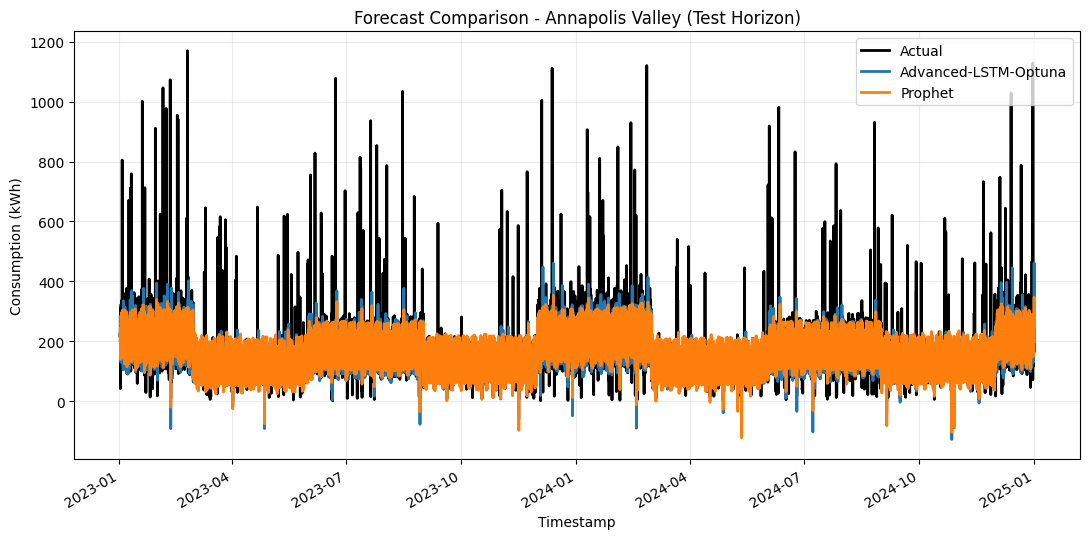

Saved forecast plot to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/forecast_plot.png
Saved forecast plot to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/report/figures/forecast_plot.png


In [152]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Combine Prophet and Tuned LSTM metrics
# We remove 'Predictions' to keep the dataframe lightweight
p_metrics = prophet_metrics_df.drop(columns='Predictions').copy()
l_metrics = best_lstm_metrics_df.drop(columns='Predictions').copy()

# 2. Merge into one master comparison table
all_metrics_df = pd.concat([p_metrics, l_metrics], ignore_index=True)

# 3. Create a Pivot Table for MAE, RMSE, and MAPE
summary_table = all_metrics_df.pivot_table(
    index='Region', 
    columns='Model', 
    values=['MAE', 'RMSE', 'MAPE']
)

# 4. Reorder columns so metrics are grouped together for easier reading
summary_table = summary_table.reorder_levels([0, 1], axis=1).sort_index(axis=1)

print("--- FINAL REGIONAL PERFORMANCE COMPARISON (All Metrics) ---")
display(summary_table.style.format("{:.2f}").highlight_min(axis=1, color='lightgreen'))

# 5. Global Model Averages (For a high-level "Executive Summary" view)
print("\n--- GLOBAL AVERAGES ACROSS ALL REGIONS ---")
global_avg = all_metrics_df.groupby('Model')[['MAE', 'RMSE', 'MAPE']].mean()
display(global_avg.style.format("{:.2f}"))

# 6. Build and save a forecast comparison plot for report use
def _build_forecast_from_metrics(metrics_df, model_name):
    rows = []
    for _, r in metrics_df.iterrows():
        reg = r['Region']
        reg_df = df[df['region'] == reg].sort_values('timestamp')
        preds = r['Predictions']
        test_dates = reg_df['timestamp'].iloc[-len(preds):].values
        rows.append(pd.DataFrame({
            'ds': test_dates,
            'yhat': preds,
            'region': reg,
            'model': model_name
        }))
    return pd.concat(rows, ignore_index=True)

if 'forecast_final' not in globals() or forecast_final is None or len(forecast_final) == 0:
    ff_prophet = _build_forecast_from_metrics(prophet_metrics_df, 'Prophet')
    ff_lstm = _build_forecast_from_metrics(best_lstm_metrics_df, 'Advanced-LSTM-Optuna')
    forecast_final = pd.concat([ff_prophet, ff_lstm], ignore_index=True)

region_to_plot = sorted(forecast_final['region'].unique())[0]
region_hist = df[df['region'] == region_to_plot].sort_values('timestamp')
region_fc = forecast_final[forecast_final['region'] == region_to_plot].sort_values('ds')
horizon = region_fc['ds'].nunique()
actual_slice = region_hist.tail(horizon)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(actual_slice['timestamp'], actual_slice['consumption_kwh'], label='Actual', color='black', linewidth=2)

for model_name, g in region_fc.groupby('model'):
    g = g.sort_values('ds')
    ax.plot(g['ds'], g['yhat'], label=model_name, linewidth=2)

ax.set_title(f'Forecast Comparison - {region_to_plot} (Test Horizon)')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Consumption (kWh)')
ax.legend()
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()

# Save into output and report figures
out_path = OUTPUT_DIR / 'forecast_plot.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
report_fig_dir = ROOT_DIR / 'report' / 'figures'
report_fig_dir.mkdir(parents=True, exist_ok=True)
report_path = report_fig_dir / 'forecast_plot.png'
fig.savefig(report_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved forecast plot to: {out_path}')
print(f'Saved forecast plot to: {report_path}')